# MAGNET Network Extraction

The MAGNET algorithm uses the traditional medial axis approach for extracting a network from an image. It makes use of the skeleton by locating pores as the junctions or endpoints of the skeleton. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import openpnm as op

import porespy as ps

ps.visualization.set_mpl_style()
np.random.seed(10)

D:\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


No module named 'pyedt'


## Generate an Image

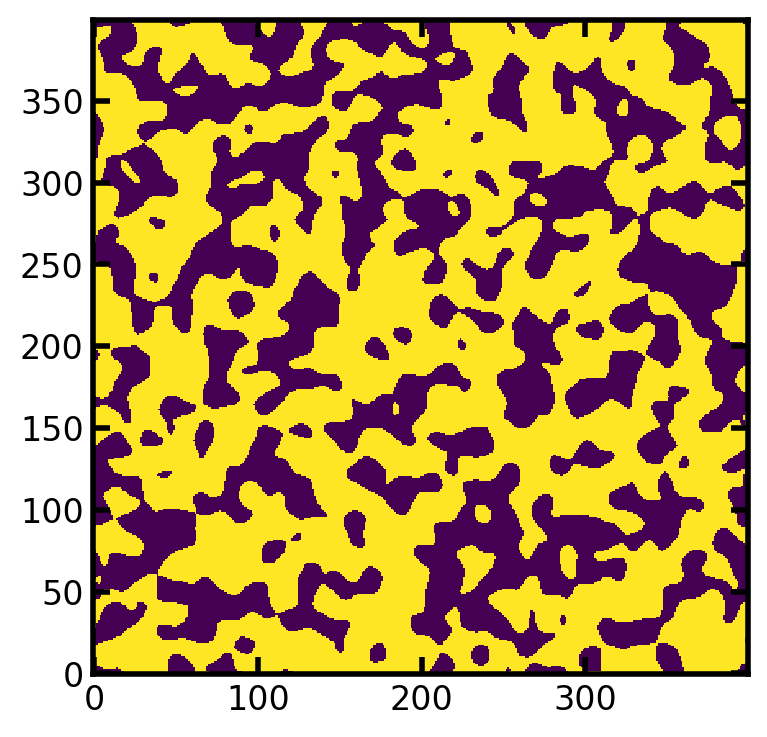

In [2]:
im = ps.generators.blobs(shape=[400, 400], porosity=0.6, blobiness=2)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(im);

MAGNET uses a series of filters to extract a pore network but porespy has one function that does all this work for you!

In [3]:
magnet_output = ps.networks.magnet(im, voxel_size=1)

D:\OneDrive - University of Waterloo\UW files\code\porespy\src\porespy\networks\_magnet.py:209: FutureWarning: `skeletonize_3d` is deprecated since version 0.23 and will be removed in version 0.25. Use `skimage.morphology.skeletonize` instead.
  sk = skeletonize(im).astype('bool')


The magnet function returns an object that has a network attribute. This is a dictionary that is suitable for loading into OpenPNM. The best way to get this into OpenPNM is to use the PoreSpy IO class. This splits the data into a network and a geometry:

In [4]:
pn = op.io.network_from_porespy(magnet_output.network)

As can be seen by printing the network it contains quite a lot of geometric information:

In [5]:
print(pn)

throat.conns
[[  0   4]
 [  2   9]
 [  5  11]
 [  3   7]
 [ 10  12]
 [  3  10]
 [  1   5]
 [  1   9]
 [  2  16]
 [  2  15]
 [  4   8]
 [  3  17]
 [  6   8]
 [  7  11]
 [  5  11]
 [  4  12]
 [  7  17]
 [  9  13]
 [  8  21]
 [ 10  12]
 [ 16  24]
 [ 11  19]
 [ 13  23]
 [ 13  15]
 [ 14  21]
 [ 15  20]
 [ 17  26]
 [ 18  25]
 [ 17  45]
 [ 21  22]
 [ 20  23]
 [ 20  33]
 [ 23  28]
 [ 25  27]
 [ 25  28]
 [ 30  37]
 [ 31  47]
 [ 29  40]
 [ 29  41]
 [ 33  47]
 [ 33  39]
 [ 34  40]
 [ 35  38]
 [ 44  45]
 [ 36  46]
 [ 41  44]
 [ 40  49]
 [ 41  49]
 [ 40  57]
 [ 42  46]
 [ 43  62]
 [ 44  49]
 [ 46  53]
 [ 44  55]
 [ 45  55]
 [ 45  60]
 [ 48  52]
 [ 47  52]
 [ 50  58]
 [ 49  56]
 [ 52  59]
 [ 53  54]
 [ 55  64]
 [ 58  62]
 [ 57  68]
 [ 57  63]
 [ 58  66]
 [ 59  65]
 [ 60  70]
 [ 60  75]
 [ 59  69]
 [ 62  74]
 [ 59  73]
 [ 63  79]
 [ 61  66]
 [ 61  69]
 [ 63  71]
 [ 64  72]
 [ 64  70]
 [ 67  68]
 [ 66  80]
 [ 69  76]
 [ 68  78]
 [ 68  71]
 [ 72  82]
 [ 70  88]
 [ 72  87]
 [ 71  83]
 [ 71  85]
 [ 73  7

You can also overlay the network on the image natively in porespy. Note that you need to transpose the image using im.T, since imshow uses matrix representation, e.g. a (10, 20)-shaped array is shown as 10 pixels in the y-axis, and 20 pixels in the x-axis.

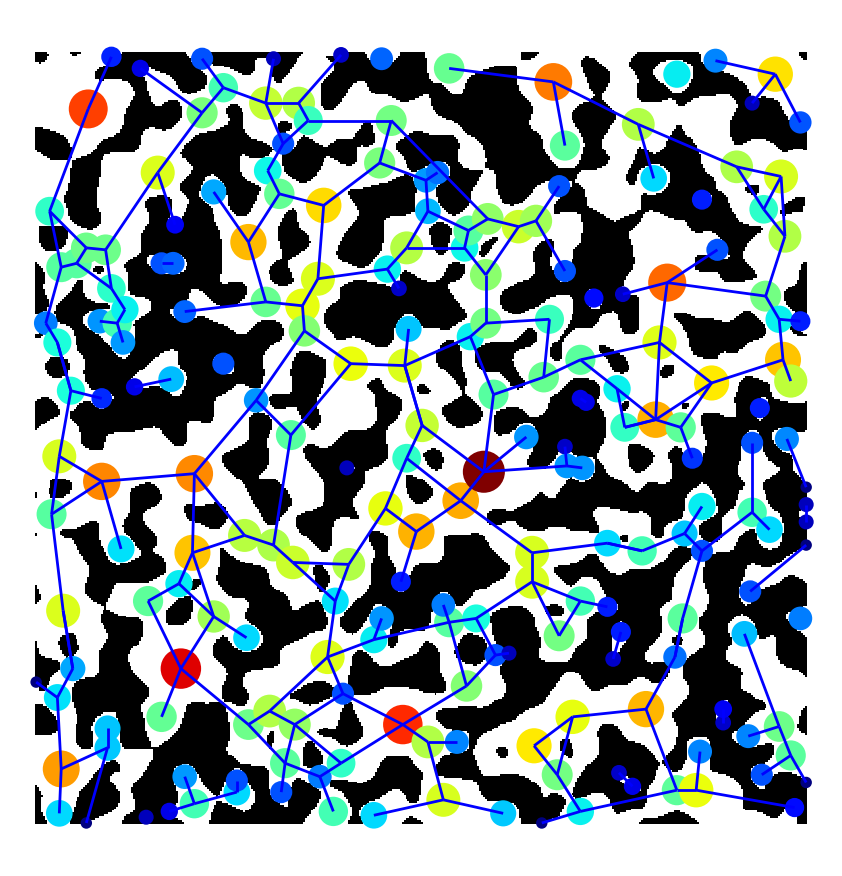

In [6]:
fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(im.T, cmap=plt.cm.bone)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  size_by=pn["pore.inscribed_diameter"],
                                  color_by=pn["pore.inscribed_diameter"],
                                  markersize=200)
op.visualization.plot_connections(network=pn, ax=fig)
ax.axis("off");